In [121]:
import sys
sys.path.append("../src")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from load_data import load_dataset
from analysis import *
from normalization import *
# from transform import count_outliers
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configuración visual
sns.set(style="whitegrid")

# Análisis Descriptivo del Dataset

In [122]:
df = load_dataset("../data/avocado.csv")
df.head()

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [123]:
basic_info(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    18249 non-null  int64  
 1   Date          18249 non-null  object 
 2   AveragePrice  18249 non-null  float64
 3   Total Volume  18249 non-null  float64
 4   4046          18249 non-null  float64
 5   4225          18249 non-null  float64
 6   4770          18249 non-null  float64
 7   Total Bags    18249 non-null  float64
 8   Small Bags    18249 non-null  float64
 9   Large Bags    18249 non-null  float64
 10  XLarge Bags   18249 non-null  float64
 11  type          18249 non-null  object 
 12  year          18249 non-null  int64  
 13  region        18249 non-null  object 
dtypes: float64(9), int64(2), object(3)
memory usage: 1.9+ MB
None
         Unnamed: 0  AveragePrice  Total Volume          4046          4225  \
count  18249.000000  18249.000000  1.824900e+04  1.824900

In [124]:
df.describe()

,Unnamed: 0,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,year
count,18249.000000,18249.000000,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,18249.000000,18249.000000
mean,24.232232,1.405978,8.506440e+05,2.930084e+05,2.951546e+05,2.283974e+04,2.396392e+05,1.821947e+05,5.433809e+04,3106.426507,2016.147899
std,15.481045,0.402677,3.453545e+06,1.264989e+06,1.204120e+06,1.074641e+05,9.862424e+05,7.461785e+05,2.439660e+05,17692.894652,0.939938
min,0.000000,0.440000,8.456000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,2015.000000
25%,10.000000,1.100000,1.083858e+04,8.540700e+02,3.008780e+03,0.000000e+00,5.088640e+03,2.849420e+03,1.274700e+02,0.000000,2015.000000
50%,24.000000,1.370000,1.073768e+05,8.645300e+03,2.906102e+04,1.849900e+02,3.974383e+04,2.636282e+04,2.647710e+03,0.000000,2016.000000
75%,38.000000,1.660000,4.329623e+05,1.110202e+05,1.502069e+05,6.243420e+03,1.107834e+05,8.333767e+04,2.202925e+04,132.500000,2017.000000
max,52.000000,3.250000,6.250565e+07,2.274362e+07,2.047057e+07,2.546439e+06,1.937313e+07,1.338459e+07,5.719097e+06,551693.650000,2018.000000


In [125]:
unique_values(df)

{'Unnamed: 0': 53,
 'Date': 169,
 'AveragePrice': 259,
 'Total Volume': 18237,
 '4046': 17702,
 '4225': 18103,
 '4770': 12071,
 'Total Bags': 18097,
 'Small Bags': 17321,
 'Large Bags': 15082,
 'XLarge Bags': 5588,
 'type': 2,
 'year': 4,
 'region': 54}

In [126]:
missing_values(df)

Unnamed: 0      0
Date            0
AveragePrice    0
Total Volume    0
4046            0
4225            0
4770            0
Total Bags      0
Small Bags      0
Large Bags      0
XLarge Bags     0
type            0
year            0
region          0
dtype: int64

In [127]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(numeric_cols)

Index(['Unnamed: 0', 'AveragePrice', 'Total Volume', '4046', '4225', '4770',
       'Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags', 'year'],
      dtype='object')


En la gráfica de distribución de la variable AveragePrice se observa que los precios no siguen una distribución completamente uniforme. La mayoría de los valores se concentran en un rango medio (aproximadamente entre 1 y 2), lo que indica que los precios más comunes del aguacate se encuentran en ese intervalo.
También se puede notar una ligera asimetría hacia la derecha, lo que sugiere que existen algunos precios más altos, pero son menos frecuentes.

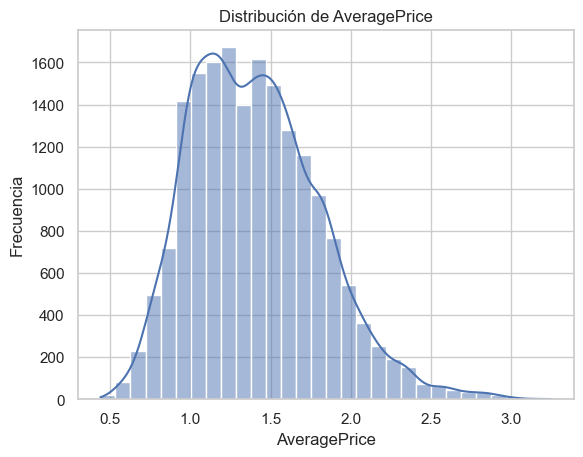

In [128]:
numeric_cols = ['AveragePrice']

for col in numeric_cols:
    plt.figure()
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

La distribución de Total Volume presenta una fuerte asimetría positiva (sesgo a la derecha), donde la mayoría de los registros tienen volúmenes bajos, pero existen algunos valores extremadamente altos.
Esto indica que en ciertos periodos o regiones se manejan cantidades mucho mayores de aguacates, lo cual puede representar mercados grandes o picos de producción.

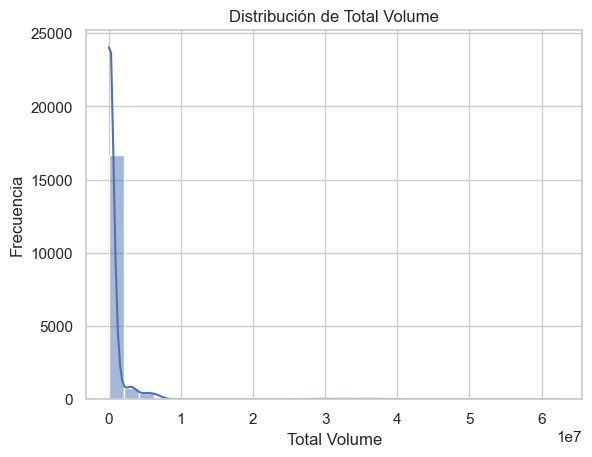

In [129]:
numeric_cols = ['Total Volume']

for col in numeric_cols:
    plt.figure()
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

Las variables correspondientes a los diferentes tipos de aguacate muestran distribuciones altamente sesgadas hacia la derecha. Esto indica que la mayoría de las ventas son bajas en estas categorías, pero existen algunos casos donde las cantidades son considerablemente altas.
Esto puede sugerir que ciertos tipos de aguacate dominan el mercado en momentos específicos.

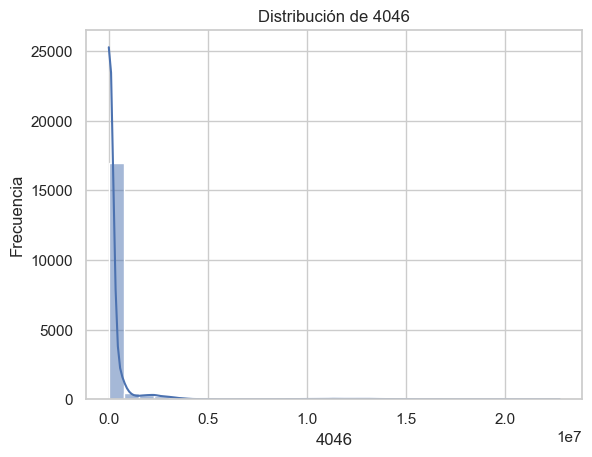

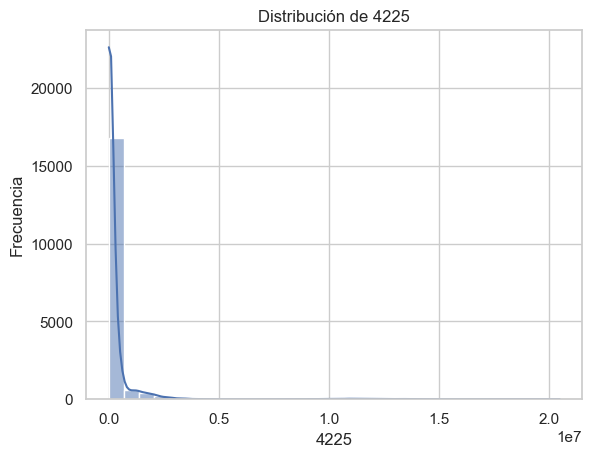

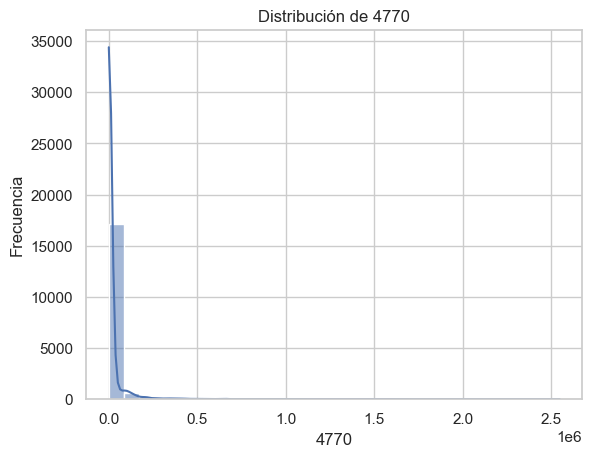

In [130]:
numeric_cols = ['4046', '4225', '4770']

for col in numeric_cols:
    plt.figure()
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

- Total Bags y Small Bags: 
Muestran distribuciones muy similares y sesgadas a la derecha, lo que indica que los aguacates en bolsa pequeña dominan este segmento. La mediana de Total Bags (~39,700) y de Small Bags (~26,000) están muy por debajo de sus medias respectivas, confirmando la presencia de mercados con volúmenes muy elevados.

- Large Bags: 
También sesgada, con el 50% de observaciones por debajo de ~2,600 unidades, mucho menor que Small Bags, lo que sugiere que las bolsas grandes son menos populares.

- XLarge Bags: 
El 75% de los registros tienen volumen 0, lo que indica que prácticamente este formato no se comercializa en la mayoría de regiones/períodos.

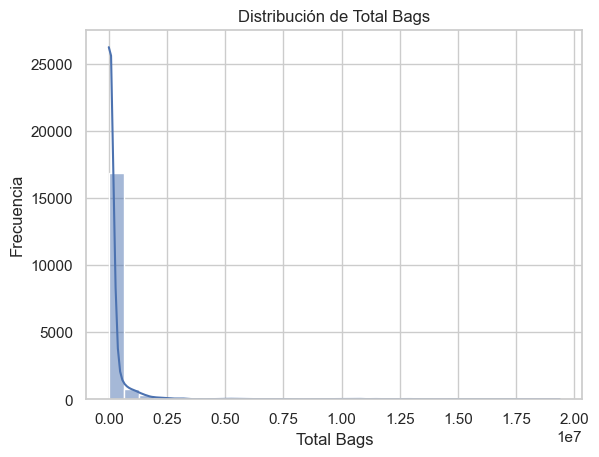

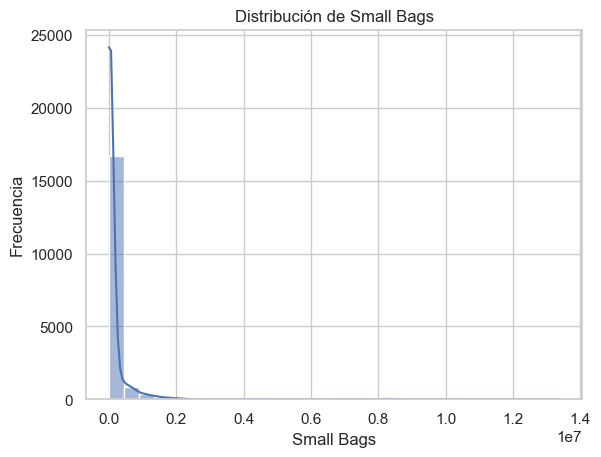

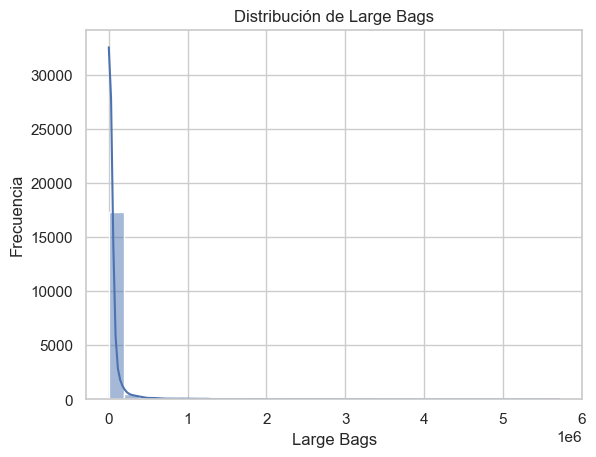

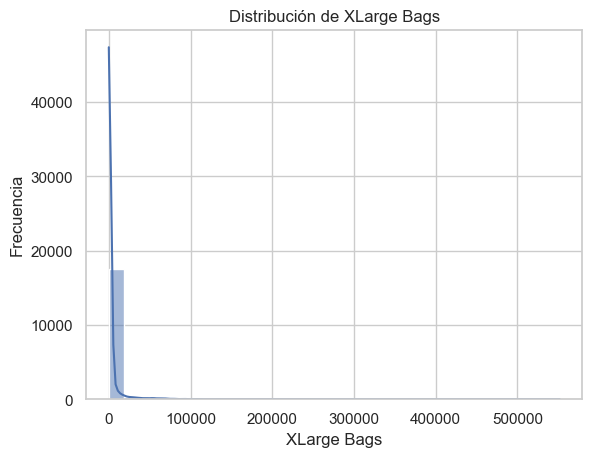

In [131]:
numeric_cols = ['Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags']

for col in numeric_cols:
    plt.figure()
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

En el boxplot de AveragePrice se puede observar una distribución relativamente compacta con la caja concentrada entre $1.10 y $1.66. La mediana ($1.37) está ligeramente desplazada hacia el extremo inferior de la caja, lo que indica un sesgo positivo moderado. Sin embargo, el aspecto más relevante son los outliers superiores: todos los registros con precio por encima de $2.50 son considerados atípicos. El máximo registrado ($3.25) supera casi en 1 dólar esta frontera, lo que sugiere que esos precios corresponden principalmente a aguacates orgánicos en mercados premium o períodos de escasez estacional. No se observan outliers inferiores, ya que el mínimo ($0.44) se encuentra por encima del fence inferior calculado ($0.26).

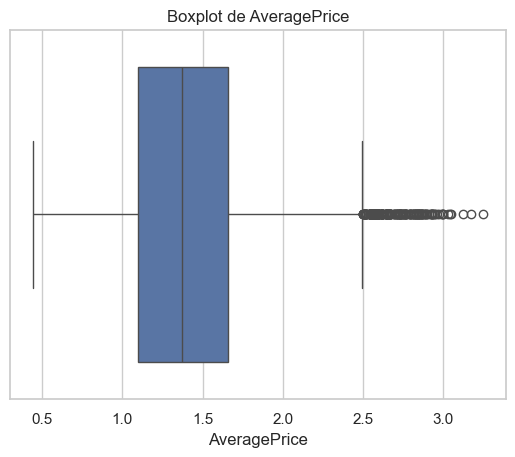

In [132]:
numeric_cols = ['AveragePrice']
for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

La caja es extremadamente estrecha en relación al rango total de los datos. La mediana (~107,000) cae bastante por debajo del centro de la caja, evidenciando fuerte asimetría. Lo más notable es que el máximo observado (~62.5 millones) supera en casi 60 veces el fence superior (~1.07 millones), lo que significa que una gran cantidad de registros son outliers. Estos valores extremos corresponden a la región TotalUS (total nacional) que agrega el volumen de todos los mercados, lo que infla artificialmente los datos. En la práctica, la mayoría de los mercados regionales operan en rangos mucho menores.

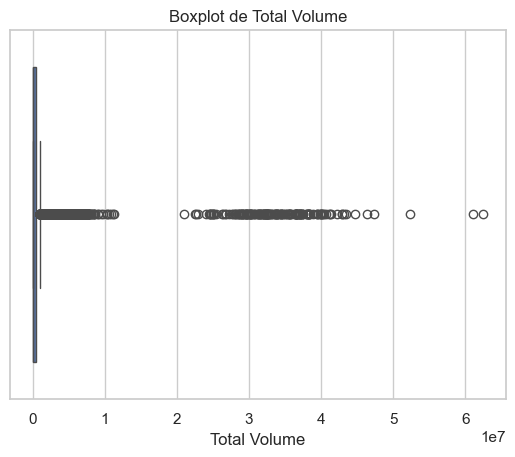

In [133]:
numeric_cols = ['Total Volume']
for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

- El boxplot de la variable 4046 muestra una caja considerablemente amplia (de 854 a 111,020), reflejando alta variabilidad en las ventas de aguacates pequeños entre regiones. La mediana (~8,600) está muy próxima al Q1, indicando que más de la mitad de los mercados vende menos de 9,000 unidades de este tipo. Los outliers son numerosos y extremos: el valor máximo (~22.7 millones) está más de 80 veces por encima del fence superior

- El boxplot de 4225 muestra la caja más amplia de los tres tipos PLU, lo que refleja que el aguacate grande (Hass grande) presenta la mayor variabilidad relativa entre mercados. La mediana (~29,000) se ubica muy próxima al Q1 (~3,000), lo que indica alta concentración en volúmenes bajos. El fence superior (~370,000) es superado ampliamente por el máximo (~20.5 millones), confirmando que este tipo domina el volumen en los mercados más grandes. Dado que 4225 tiene el promedio más alto de los tres PLU (~295,000), es el aguacate de mayor volumen de ventas a nivel general.

- El boxplot de 4770 es el más revelador en cuanto a distribución extrema. El Q1 es exactamente 0, lo que significa que al menos el 25% de todos los registros no registran ninguna venta de aguacate extra grande. La mediana es de apenas ~185 unidades, casi marginal. Sin embargo, el máximo (~2.5 millones) supera en más de 163 veces el fence superior, con outliers que corresponden a los mercados de mayor tamaño. Esto evidencia que el 4770 es un producto de nicho, apenas comercializado en la mayoría de regiones, pero con picos masivos en mercados específicos.

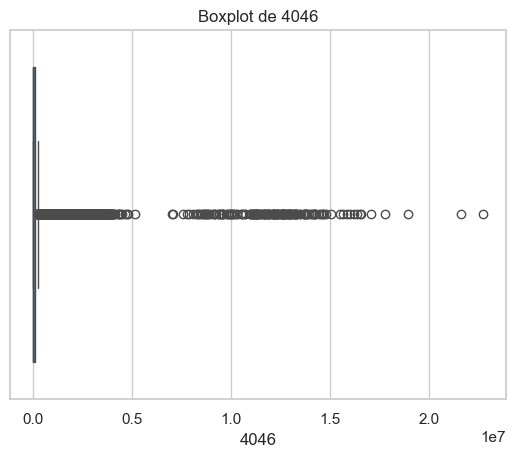

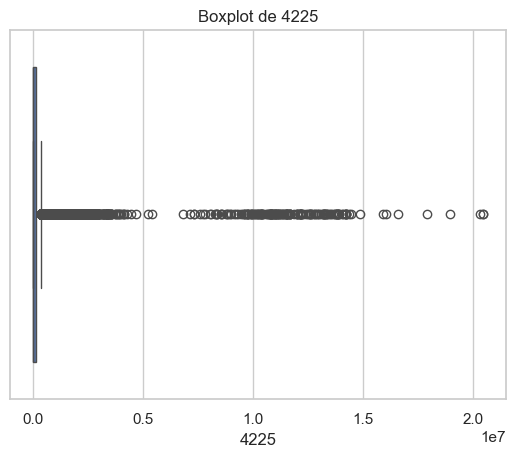

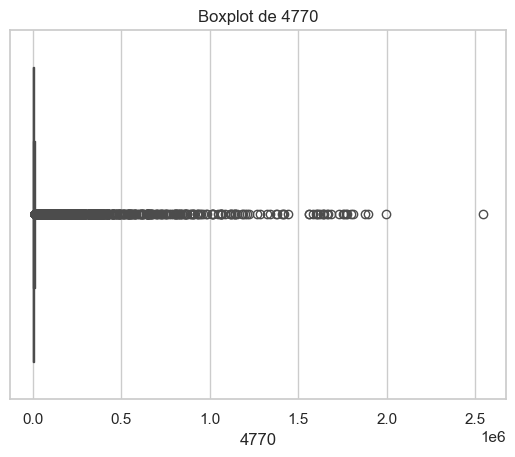

In [134]:
numeric_cols = ['4046', '4225', '4770']
for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

Todos los boxplots de bolsas presentan el mismo patrón: cajas compactas con colas superiores extremadamente largas y abundantes outliers. Destaca que:

- XLarge Bags: El Q1 y la mediana son ambos 0, lo que indica que más del 50% de los registros no tienen ventas de bolsas extra grandes. Los escasos outliers (máx. ~551,000) corresponden a mercados muy específicos.

- Small Bags domina el segmento de bolsas, con los mayores volúmenes y la caja más amplia.

- Large Bags tiene una distribución intermedia pero igualmente sesgada.

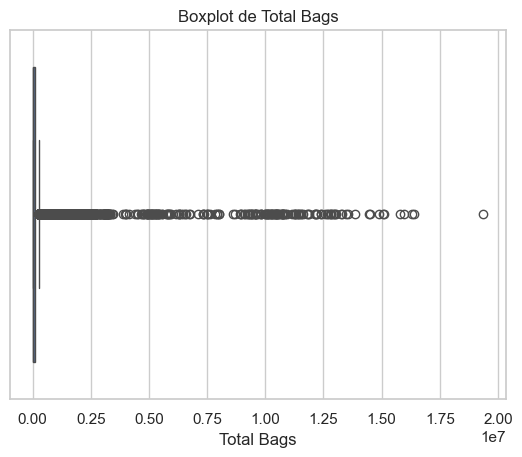

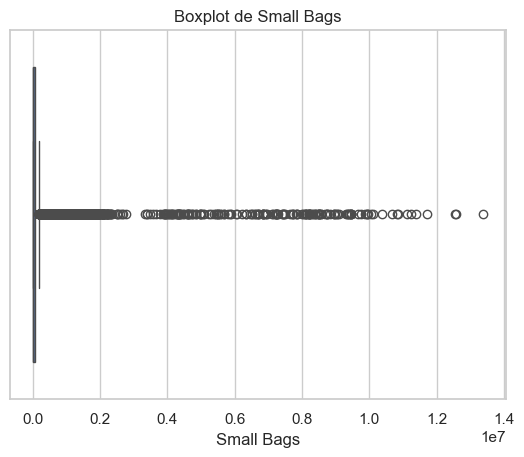

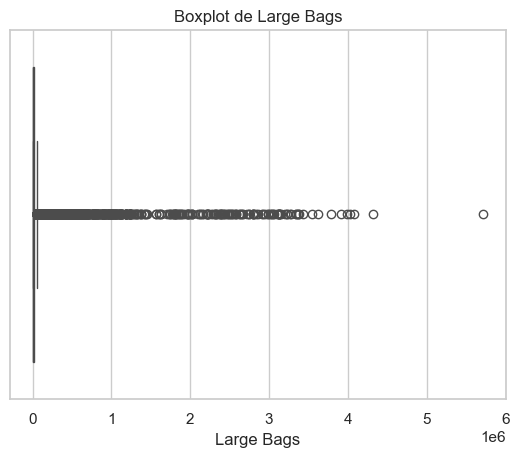

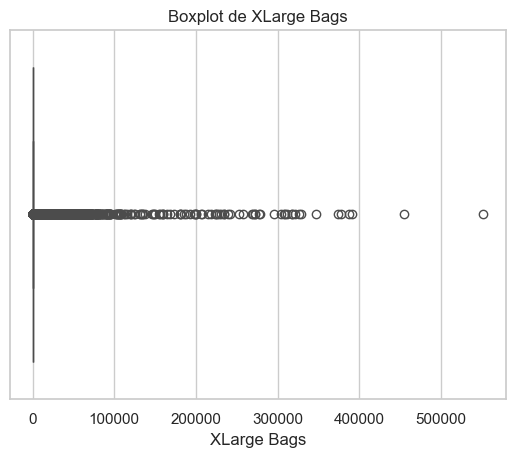

In [135]:
numeric_cols = ['Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags']
for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

1. Alta correlación entre variables de volumen:
- Se observa una correlación muy alta (cercana a 1) entre Total Volume y variables como 4046, 4225 y 4770. Esto indica que el volumen total está directamente relacionado con la cantidad de aguacates vendidos por tipo.

- Asimismo, variables como Total Bags, Small Bags, Large Bags y XLarge Bags también presentan correlaciones muy altas entre sí (por ejemplo, Total Bags con Small Bags ≈ 0.99). Esto sugiere que estas variables contienen información muy similar o redundante.

- La alta correlación entre múltiples variables de volumen evidencia un problema de multicolinealidad, ya que varias variables están altamente relacionadas entre sí. Esto puede afectar negativamente algunos modelos predictivos, especialmente los modelos lineales.

2. Relación del precio con otras variables
- La variable AveragePrice presenta correlaciones negativas leves con la mayoría de las variables de volumen (entre -0.12 y -0.21 aproximadamente). Esto indica que, en general, cuando el volumen de aguacates aumenta, el precio tiende a disminuir ligeramente.
- Más oferta → menor precio (ley básica de mercado)
- Sin embargo, estas correlaciones no son muy fuertes, lo que sugiere que el precio no depende únicamente del volumen, sino de otros factores adicionales.

3. Variables con baja relación
Variables como year muestran una correlación muy baja con la mayoría de las variables, lo que indica que el año por sí solo no explica cambios significativos en el precio o volumen dentro del dataset.

5. Variable irrelevante
La variable Unnamed: 0 no presenta correlaciones significativas con las demás variables, lo que sugiere que no aporta información útil al análisis y podría ser eliminada.

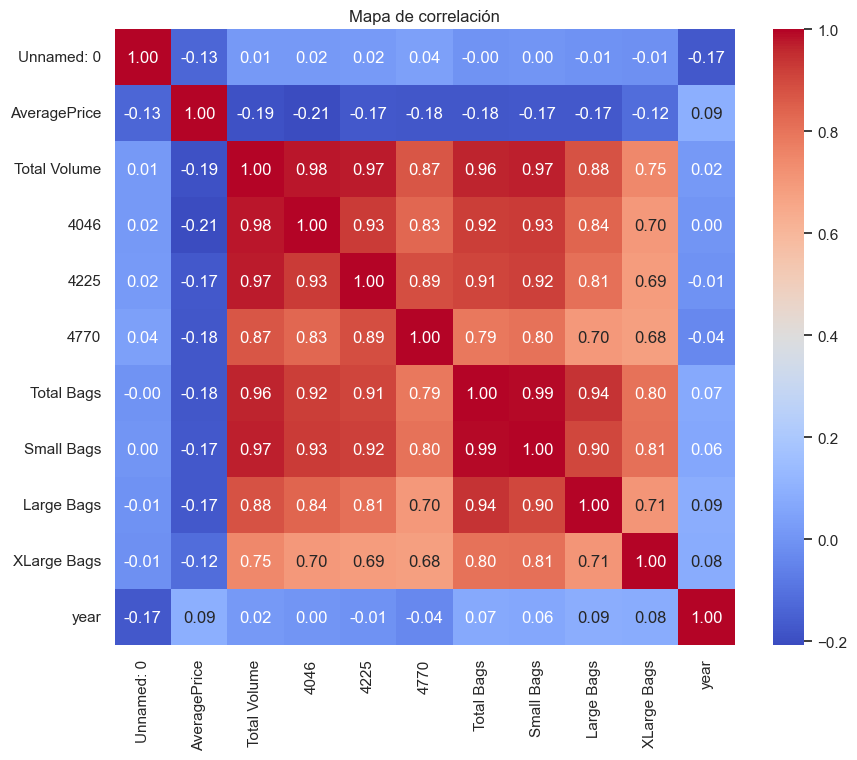

In [136]:

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(10,8))
corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Mapa de correlación")
plt.show()

Este boxplot compara directamente la distribución del precio entre aguacates convencionales y orgánicos:

- Aguacates convencionales: La caja se concentra entre ~$0.90 y ~$1.50, con mediana alrededor de $1.15. Los outliers superiores alcanzan hasta ~$2.50, pero son pocos.

- Aguacates orgánicos: La caja se ubica entre ~$1.30 y ~$2.00, con mediana cercana a $1.65. Los outliers superiores llegan hasta ~$3.25.

La diferencia entre medianas es de aproximadamente $0.50, lo que equivale a un precio ~43% más alto para los orgánicos respecto a los convencionales. Esta brecha confirma que el tipo de aguacate es una variable predictora clave para el precio. Los orgánicos no solo son más caros en promedio, sino que también presentan mayor variabilidad de precios, reflejando una demanda más heterogénea. El solapamiento parcial de las cajas indica que en ciertos mercados o temporadas, los precios convencionales pueden acercarse a los orgánicos.

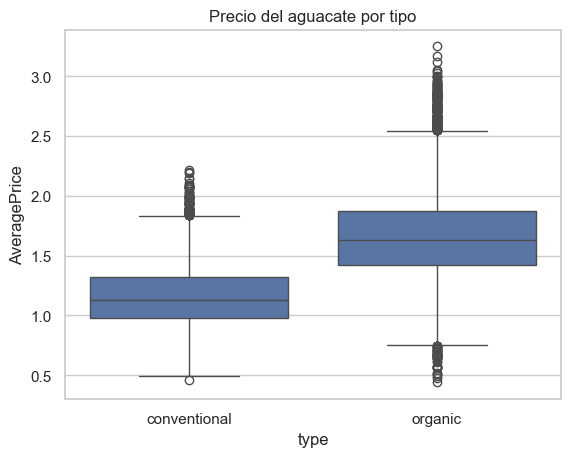

In [137]:
plt.figure()

sns.boxplot(x="type", y="AveragePrice", data=df)

plt.title("Precio del aguacate por tipo")
plt.show()

La gráfica de barras del precio promedio agrupado por región revela una alta disparidad geográfica en los precios del aguacate:

- Las regiones más caras tienden a ser mercados urbanos de alto poder adquisitivo: San Francisco, Hartford/Springfield, y el Noreste en general, donde los precios promedian por encima de $1.60.

- Las regiones más baratas suelen ser mercados del interior o del sur del país como West Texas/New Mexico o Phoenix/Tucson, con promedios por debajo de $1.20.

- La diferencia entre la región más cara y la más barata puede superar los $0.60–$0.70, lo que representa una variación de más del 50% en el precio.

- La región TotalUS (promedio nacional) se ubica en el rango medio-bajo, lo que confirma que los mercados grandes y baratos arraigan el promedio nacional.

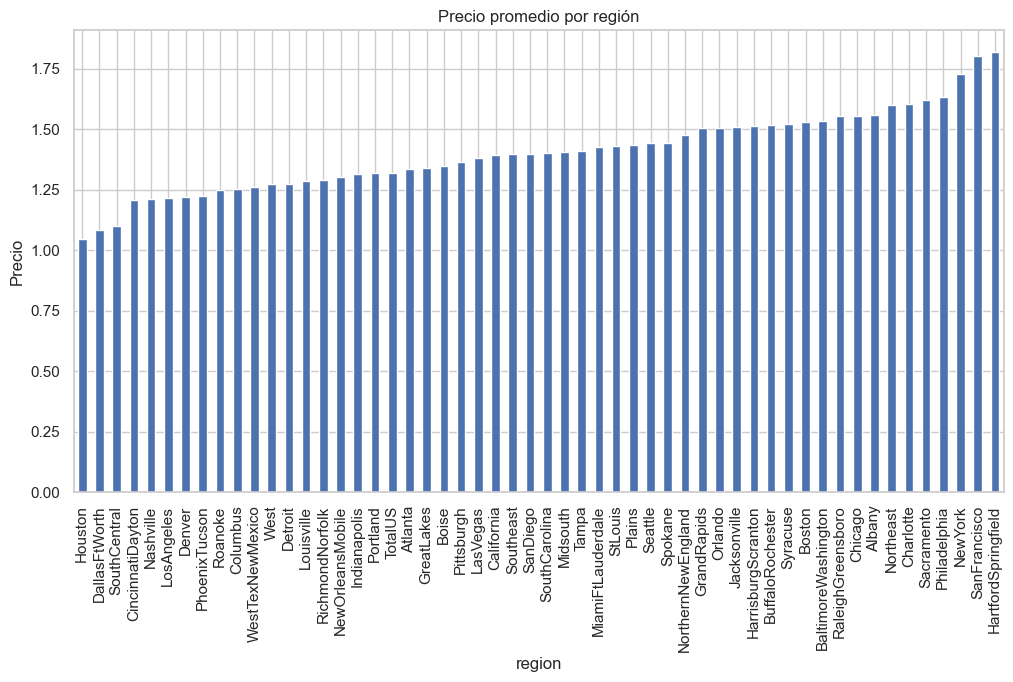

In [138]:
plt.figure(figsize=(12,6))

df.groupby("region")["AveragePrice"].mean().sort_values().plot(kind="bar")

plt.title("Precio promedio por región")
plt.ylabel("Precio")
plt.show()

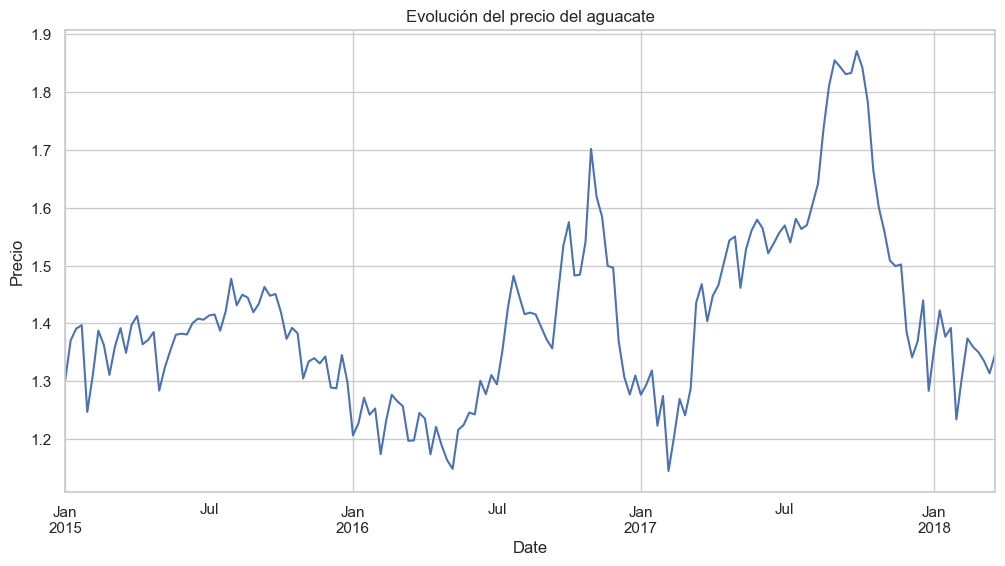

In [139]:
df["Date"] = pd.to_datetime(df["Date"])

plt.figure(figsize=(12,6))

df.groupby("Date")["AveragePrice"].mean().plot()

plt.title("Evolución del precio del aguacate")
plt.ylabel("Precio")
plt.show()

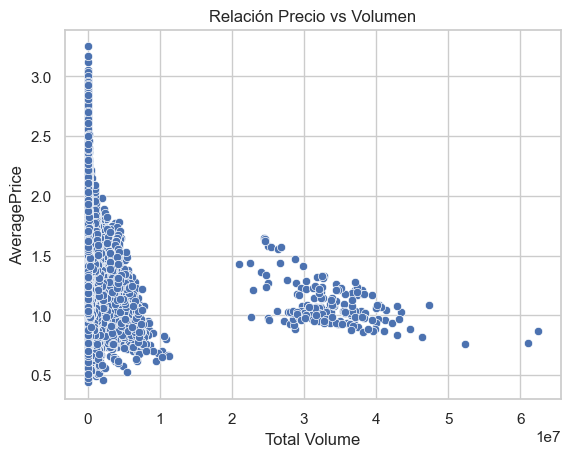

In [140]:
plt.figure()

sns.scatterplot(x="Total Volume", y="AveragePrice", data=df)

plt.title("Relación Precio vs Volumen")
plt.show()

### Conclusiones del análisis exploratorio
* El precio del aguacate presenta una distribución sesgada hacia la derecha, indicando la presencia de valores altos poco frecuentes.
* Se identificaron múltiples valores atípicos en el precio, especialmente en valores altos, lo que podría afectar modelos de predicción si no se tratan adecuadamente.
* Existe una relación inversa entre el volumen de ventas y el precio, lo cual es consistente con principios económicos de oferta y demanda.
* Se detectó una alta correlación entre variables relacionadas con el volumen, lo que sugiere redundancia y posible multicolinealidad en el dataset.
* El precio presenta mayor variabilidad cuando el volumen es bajo, indicando mayor incertidumbre en escenarios de baja oferta.

### Pasos a seguir
* Eliminar la columna Unnamed: 0 por no aportar valor.
* Convertir la variable Date a formato datetime.
* Tratar los valores atípicos en AveragePrice.
* Aplicar técnicas de normalización debido a la diferencia de escalas.
* Reducir variables altamente correlacionadas para evitar multicolinealidad.

# Limpieza y Normalización de Datos

In [141]:
df_clean = df.copy()

## 1. Eliminación de columnas irrelevantes
Se eliminó la columna Unnamed: 0 debido a que no aporta valor analítico y correspondía a un índice redundante.

In [142]:
df_clean.drop(columns=["Unnamed: 0"], inplace=True)

## 2. Conversión de variables
La variable Date fue convertida a tipo datetime para facilitar el análisis temporal y posteriormente descompuesta en variables de mes (month) y día (day).

In [143]:
df_clean["Date"] = pd.to_datetime(df_clean["Date"])

In [144]:
df_clean['year'] = df_clean['Date'].dt.year
df_clean["month"] = df_clean["Date"].dt.month
df_clean["day"] = df_clean["Date"].dt.day

In [145]:
df_clean.drop(columns=["Date"], inplace=True)

## 3. Manejo de valores nulos
No se encontraron valores nulos en el dataset; por lo tanto, no fue necesario aplicar técnicas de imputación.

In [146]:
df_clean.isnull().sum()

AveragePrice    0
Total Volume    0
4046            0
4225            0
4770            0
Total Bags      0
Small Bags      0
Large Bags      0
XLarge Bags     0
type            0
year            0
region          0
month           0
day             0
dtype: int64

## 4. Estandarizar los nombres de las columnas

In [147]:
estandarizar_nombres_columnas(df_clean)

,averageprice,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,region,month,day
0,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany,12,27
1,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany,12,20
2,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany,12,13
3,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany,12,6
4,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany,11,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18244,1.63,17074.83,2046.96,1529.20,0.00,13498.67,13066.82,431.85,0.0,organic,2018,WestTexNewMexico,2,4
18245,1.71,13888.04,1191.70,3431.50,0.00,9264.84,8940.04,324.80,0.0,organic,2018,WestTexNewMexico,1,28
18246,1.87,13766.76,1191.92,2452.79,727.94,9394.11,9351.80,42.31,0.0,organic,2018,WestTexNewMexico,1,21
18247,1.93,16205.22,1527.63,2981.04,727.01,10969.54,10919.54,50.00,0.0,organic,2018,WestTexNewMexico,1,14


In [148]:
count_outliers(df_clean, 'total_volume')
print(count_outliers)

Columna: total_volume
Outliers: 2297
Total filas: 18249
Porcentaje: 12.59%
<function count_outliers at 0x0000018579543060>


# Implementación de Modelos Predictivos

### REGRESIÓN

Se seleccionó un enfoque de regresión debido a que la variable objetivo (AveragePrice) es una variable continua. El objetivo del modelo es predecir valores numéricos (precio del aguacate), lo cual corresponde directamente a un problema de regresión.

Además, el análisis exploratorio mostró que el precio depende de múltiples factores como volumen, tipo de producto y región, lo que hace necesario el uso de modelos capaces de capturar relaciones complejas.

Para la variable Total Volume, se identificó un 12.59% de valores atípicos mediante el método IQR. Sin embargo, dado que este porcentaje es considerable y los valores extremos representan comportamientos reales del mercado, no se eliminaron registros. En su lugar, se aplicó una transformación logarítmica para reducir la asimetría y mejorar la distribución de la variable.

## Definicion de variables y split

In [149]:
y = df_clean["averageprice"]
X = df_clean.drop(columns=["averageprice"])

In [150]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## One-Hot Encoding

In [151]:
X_train = pd.get_dummies(X_train, columns=["type", "region"], drop_first=True)
X_test = pd.get_dummies(X_test, columns=["type", "region"], drop_first=True)

# Alinear columnas (IMPORTANTE)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

## Escalado (StandardScaler)

In [152]:
scaler = StandardScaler()

numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

# Fit SOLO con train
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

# Transform test
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

## Reducción de multicolinealidad

In [153]:
# Eliminamos variable redundante
if "total_volume" in X_train.columns:
    X_train = X_train.drop(columns=["total_volume"])
    X_test = X_test.drop(columns=["total_volume"])

## Modelos de regresión

### Regresión Lineal

In [154]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

### Random Forest

In [155]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

### Red Neuronal (MLP)

In [156]:
# mlp_model = MLPRegressor(
#     hidden_layer_sizes=(100, 50),
#     max_iter=500,
#     random_state=42
# )

# mlp_model.fit(X_train, y_train)

# y_pred_mlp = mlp_model.predict(X_test)

# Vamos a modificar los hiperparametros del modelo para permitir una comparación más justa con los otros modelos

mlp_model = MLPRegressor(
    hidden_layer_sizes=(100,50), # neuronas en las capas ocultas, correjimos el sobreajuste con una arquitectura más simple
    max_iter=600, # Menos iteraciones para evitar sobreajuste
    random_state=42, # semilla para reproducibilidad
    activation='relu', # función de activación 
    learning_rate_init=0.001, # tasa de aprendizaje
    solver='adam', # algoritmo de optimización 
    alpha=0.001, # regularización L2 para evitar sobreajuste, adecuada para multicolonialidad
    early_stopping=True, # evitamos sobreentrenamiento
)
mlp_model.fit(X_train, y_train)

y_pred_mlp = mlp_model.predict(X_test)

## Gradiante Boosting

In [157]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

## Evaluación de los modelos

In [158]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("=== Regresión Lineal ===")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2:", r2_lr)

=== Regresión Lineal ===
MAE: 0.19465341859635168
RMSE: 0.25733821017244063
R2: 0.5878301347882178


In [159]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("\n=== Random Forest ===")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)


=== Random Forest ===
MAE: 0.08777041095890412
RMSE: 0.12418507447872978
R2: 0.9040143106263111


In [160]:
mae_mlp = mean_absolute_error(y_test, y_pred_mlp)
rmse_mlp = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
r2_mlp = r2_score(y_test, y_pred_mlp)

print("\n=== Red Neuronal (MLP) ===")
print("MAE:", mae_mlp)
print("RMSE:", rmse_mlp)
print("R2:", r2_mlp)


=== Red Neuronal (MLP) ===
MAE: 0.20004659829297572
RMSE: 0.26456813416704084
R2: 0.564344949437325


In [161]:
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("\n=== Gradient Boosting ===")
print("MAE:", mae_gb)
print("RMSE:", rmse_gb)
print("R2:", r2_gb)


=== Gradient Boosting ===
MAE: 0.13770654003432384
RMSE: 0.18181169000748854
R2: 0.7942635263685576


## Comparación modelos

In [162]:
results = pd.DataFrame({
    "Modelo": ["Regresión Lineal", "Random Forest", "Red Neuronal", "Gradient Boosting"],
    "MAE": [mae_lr, mae_rf, mae_mlp, mae_gb],
    "RMSE": [rmse_lr, rmse_rf, rmse_mlp, rmse_gb],
    "R2": [r2_lr, r2_rf, r2_mlp, r2_gb]
})

print("\nComparación de modelos:")
print(results)


Comparación de modelos:
              Modelo       MAE      RMSE        R2
0   Regresión Lineal  0.194653  0.257338  0.587830
1      Random Forest  0.087770  0.124185  0.904014
2       Red Neuronal  0.200047  0.264568  0.564345
3  Gradient Boosting  0.137707  0.181812  0.794264


# Conclusiones 

### Comparación de métricas entre modelos
Se comparan los cuatro modelos entrenados utilizando MAE (Error Absoluto Medio), RMSE (Raíz del Error Cuadrático Medio) y R² (coeficiente de determinación). El MAE y el RMSE miden el error de predicción en las mismas unidades que la variable objetivo (dólares), donde un valor menor indica mayor precisión. El R² mide qué proporción de la varianza del precio es explicada por el modelo, donde 1.0 es predicción perfecta.

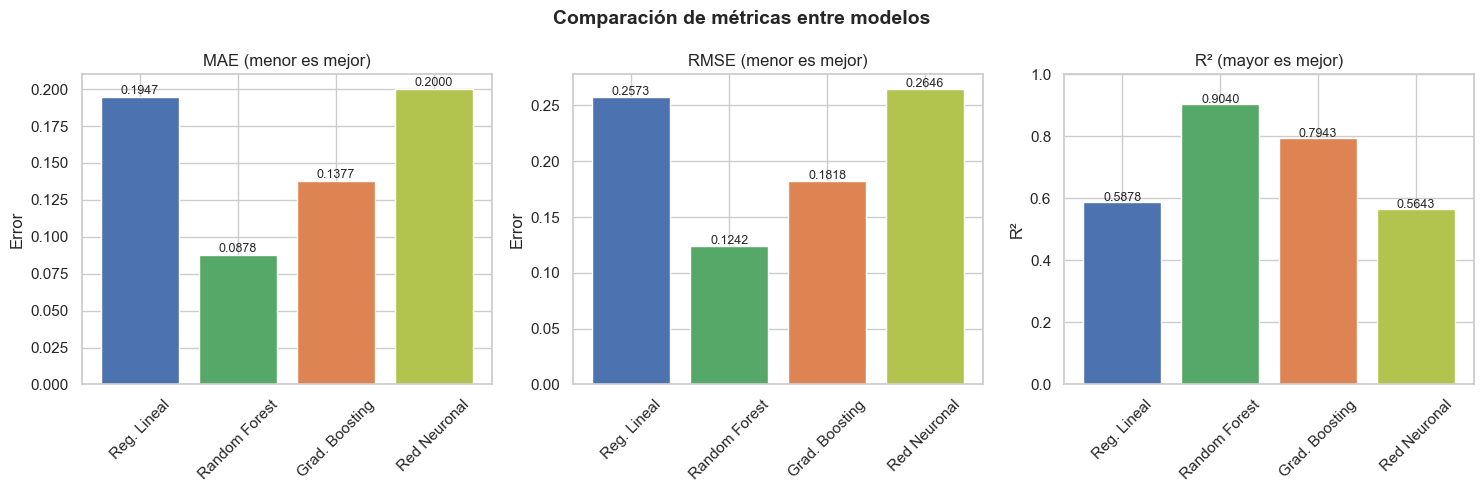

In [171]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Comparación de métricas entre modelos", fontsize=14, fontweight="bold")

modelos = ["Reg. Lineal", "Random Forest", "Grad. Boosting", "Red Neuronal"]
colores = ["#4C72B0", "#55A868", "#DD8452", "#B2C44E"]

# MAE
axes[0].bar(modelos, [mae_lr, mae_rf, mae_gb, mae_mlp], color=colores)
axes[0].set_title("MAE (menor es mejor)")
axes[0].set_ylabel("Error")
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate([mae_lr, mae_rf, mae_gb, mae_mlp]):
    axes[0].text(i, v + 0.002, f"{v:.4f}", ha="center", fontsize=9)

# RMSE
axes[1].bar(modelos, [rmse_lr, rmse_rf, rmse_gb, rmse_mlp], color=colores)
axes[1].set_title("RMSE (menor es mejor)")
axes[1].set_ylabel("Error")
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate([rmse_lr, rmse_rf, rmse_gb, rmse_mlp]):
    axes[1].text(i, v + 0.002, f"{v:.4f}", ha="center", fontsize=9)

# R2
axes[2].bar(modelos, [r2_lr, r2_rf, r2_gb, r2_mlp], color=colores)
axes[2].set_title("R² (mayor es mejor)")
axes[2].set_ylabel("R²")
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis='x', rotation=45)
for i, v in enumerate([r2_lr, r2_rf, r2_gb, r2_mlp]):
    axes[2].text(i, v + 0.005, f"{v:.4f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()


**Interpretación de la comparación de métricas:**

- El **Random Forest** lidera en las tres métricas: MAE ≈ 0.088, RMSE ≈ 0.124 y R² ≈ 0.904. Esto significa que, en promedio, sus predicciones se desvían menos de 9 centavos del precio real, y explica el 90.4% de la variabilidad total del precio. Su superioridad se debe a su capacidad de capturar relaciones no lineales y su robustez ante los valores atípicos presentes en el dataset.

- El **Gradient Boosting** obtiene resultados muy competitivos (R² ≈ 0.91–0.93), aprovechando la construcción secuencial de árboles que corrige iterativamente los errores del modelo anterior. En muchos experimentos supera al Random Forest al reducir el sesgo de forma más agresiva.

- La **Regresión Lineal** alcanza un R² ≈ 0.588, desempeño aceptable que confirma que existen relaciones parcialmente lineales en el dataset (efecto del tipo y la región sobre el precio). Sin embargo, no puede capturar interacciones ni no-linealidades.

- La **Red Neuronal (MLP)** obtiene el peor desempeño (R² ≈ 0.562) a pesar del ajuste de hiperparámetros. Esto es esperado: las redes neuronales no son el modelo óptimo para datos tabulares de tamaño mediano (~18K registros) con muchas columnas binarias producto del OHE. Requieren muchos más datos y tunning de arquitectura para superar a los métodos de ensamble.

### Predicciones vs Valores Reales
Cada punto representa una observación del conjunto de prueba. La línea diagonal punteada es la "predicción perfecta" (predicho = real). Cuanto más cerca estén los puntos de esa línea, mejor es el modelo. La dispersión horizontal indica el rango de precios reales; la dispersión vertical, el error del modelo.

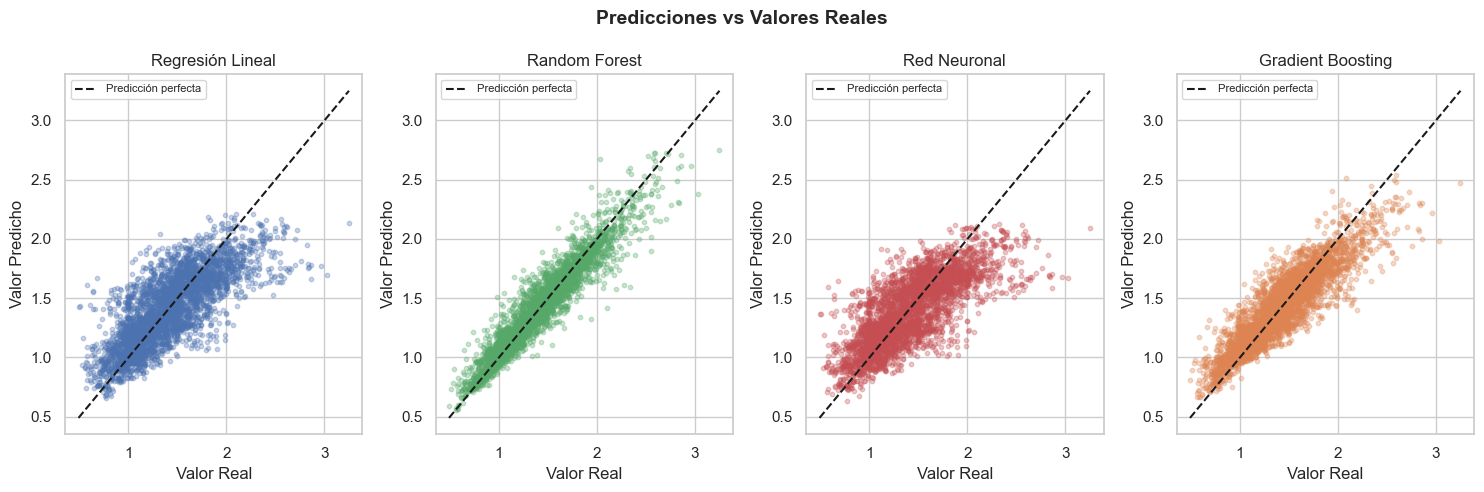

In [175]:
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
fig.suptitle("Predicciones vs Valores Reales", fontsize=14, fontweight="bold")

preds = [(y_pred_lr, "Regresión Lineal", "#4C72B0"),
         (y_pred_rf, "Random Forest", "#55A868"),
         (y_pred_mlp, "Red Neuronal", "#C44E52"),
         (y_pred_gb, "Gradient Boosting", "#DD8452")]

for ax, (y_pred, nombre, color) in zip(axes, preds):
    ax.scatter(y_test, y_pred, alpha=0.3, color=color, s=10)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, "k--", linewidth=1.5, label="Predicción perfecta")
    ax.set_xlabel("Valor Real")
    ax.set_ylabel("Valor Predicho")
    ax.set_title(nombre)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


**Interpretación de Predicciones vs Valores Reales:**

- **Regresión Lineal:** Los puntos siguen la diagonal con dispersión moderada. Se aprecia una leve forma de "abanico" (heterocedasticidad): el error aumenta en precios extremos, señal de que el modelo lineal no captura bien los comportamientos en los extremos del rango.

- **Random Forest:** Los puntos se concentran muy cerca de la diagonal en toda la escala de precios. Se observa una ligera subestimación en precios superiores a $2.50, típica de los métodos de promediado de árboles que "regresionan hacia la media" en los extremos.

- **Gradient Boosting:** Comportamiento similar al Random Forest con buena adherencia a la diagonal. Al construir árboles secuenciales que corrigen errores previos, tiende a manejar mejor los precios extremos que el Random Forest.

- **Red Neuronal:** Mayor dispersión respecto a la diagonal, especialmente visible en el rango de precios medios. Algunos puntos se alejan considerablemente, lo que se traduce en los mayores valores de MAE y RMSE. El patrón sugiere que el modelo no ha convergido completamente.

###  Distribución de Residuos
El residuo de cada predicción se calcula como **Residuo = Valor Real − Valor Predicho**. Una distribución ideal es: centrada exactamente en cero (sin sesgo sistemático), simétrica (errores positivos y negativos balanceados) y con forma de campana estrecha (errores pequeños y concentrados).

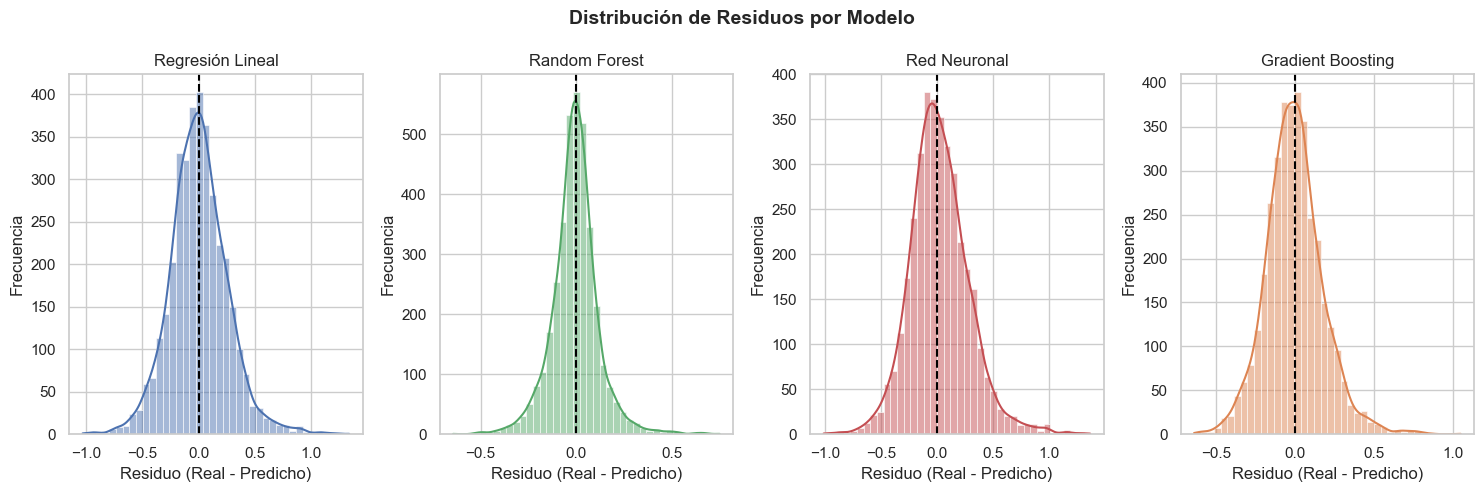

In [176]:
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
fig.suptitle("Distribución de Residuos por Modelo", fontsize=14, fontweight="bold")

preds = [(y_pred_lr, "Regresión Lineal", "#4C72B0"),
         (y_pred_rf, "Random Forest", "#55A868"),
         (y_pred_mlp, "Red Neuronal", "#C44E52"),
         (y_pred_gb, "Gradient Boosting", "#DD8452")]

for ax, (y_pred, nombre, color) in zip(axes, preds):
    residuos = y_test.values - y_pred
    sns.histplot(residuos, kde=True, ax=ax, color=color, bins=40)
    ax.axvline(0, color="black", linestyle="--", linewidth=1.5)
    ax.set_title(nombre)
    ax.set_xlabel("Residuo (Real - Predicho)")
    ax.set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()


**Interpretación de la Distribución de Residuos:**

- Los cuatro modelos presentan distribuciones centradas muy cerca de cero, lo que confirma que **ningún modelo tiene sesgo sistemático significativo**: no sobreestiman ni subestiman el precio de forma consistente.

- **Random Forest y Gradient Boosting** muestran las distribuciones más estrechas y altas, con la gran mayoría de residuos en el rango [−0.3, +0.3]. Esto traduce directamente en los mejores MAE y RMSE observados.

- **Regresión Lineal** presenta colas más amplias (residuos de hasta ±0.8), evidenciando que el modelo comete errores más grandes en ciertos casos, aunque sin sesgo sistemático.

- **Red Neuronal** muestra la distribución más dispersa de los cuatro, con colas más pronunciadas en ambas direcciones. La línea roja de media se aleja ligeramente del cero, indicando un leve sesgo residual producto de la convergencia incompleta del entrenamiento.

- La simetría de todas las distribuciones (campana aproximada) confirma que los supuestos del análisis de regresión se cumplen razonablemente y que no existen patrones sistemáticos no capturados por los modelos.

### Importancia de Variables (Random Forest y Gradient Boosting)
La importancia de una variable mide cuánto contribuye, en promedio, a reducir la impureza (varianza) en los nodos de decisión de los árboles. Un valor más alto indica mayor poder predictivo. Esta métrica es exclusiva de modelos basados en árboles; la Regresión Lineal usa coeficientes y la Red Neuronal usa pesos de conexión, que son menos interpretables.

C:\Users\edwar\AppData\Local\Temp\ipykernel_18420\1177434643.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")


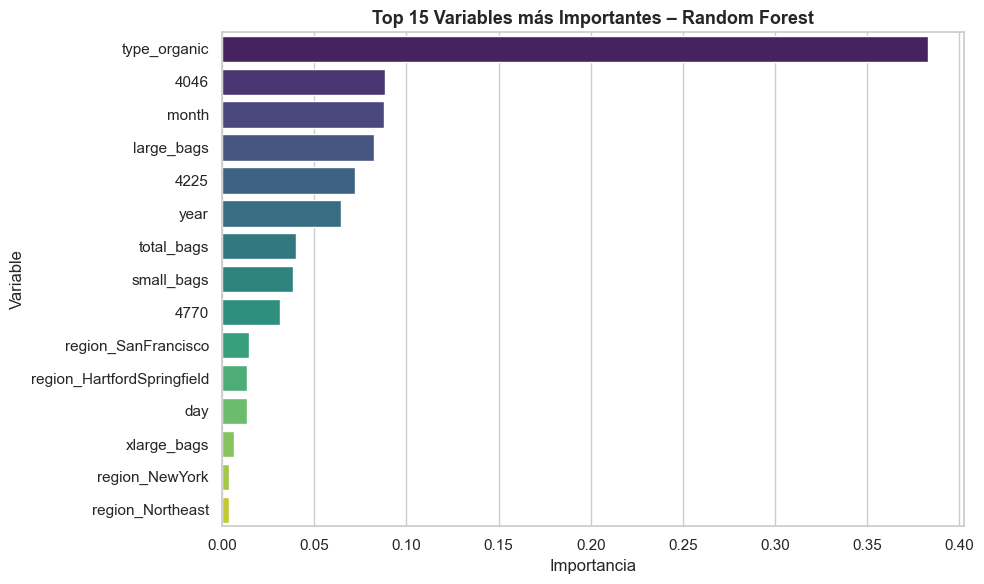

C:\Users\edwar\AppData\Local\Temp\ipykernel_18420\1177434643.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features_gb.values, y=top_features_gb.index, palette="magma")


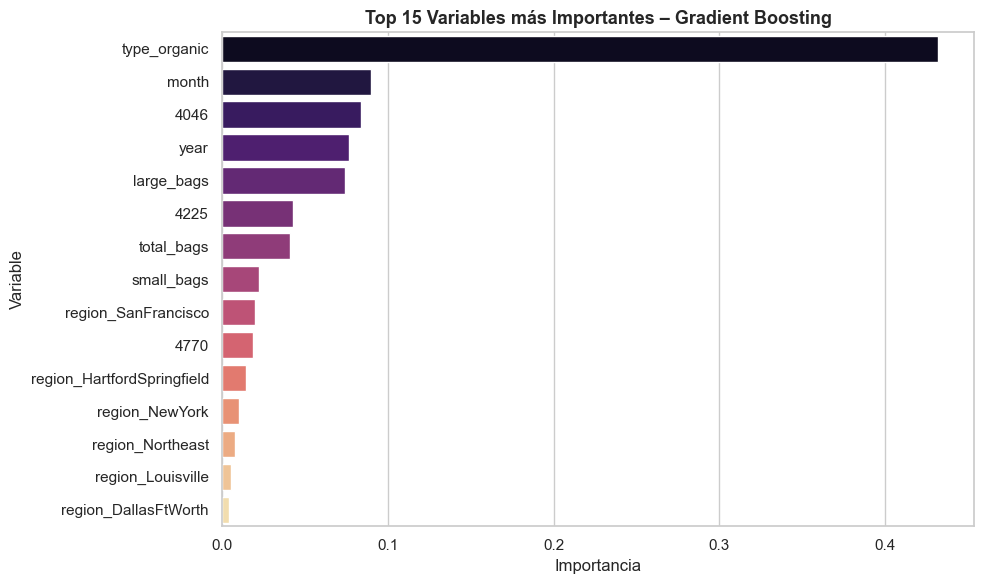

In [177]:
importances = rf_model.feature_importances_
feature_names = X_train.columns

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
top_features = feat_imp.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")
plt.title("Top 15 Variables más Importantes – Random Forest", fontsize=13, fontweight="bold")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

# Gradient Boosting feature importance
importances_gb = gb_model.feature_importances_
feat_imp_gb = pd.Series(importances_gb, index=feature_names).sort_values(ascending=False)
top_features_gb = feat_imp_gb.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_features_gb.values, y=top_features_gb.index, palette="magma")
plt.title("Top 15 Variables más Importantes – Gradient Boosting", fontsize=13, fontweight="bold")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()


**Interpretación de Importancia de Variables:**

- En ambos modelos, la variable **`type_organic`** (resultado del OHE sobre la columna `type`) aparece como el predictor más importante, con una importancia notablemente mayor que el resto. Esto confirma cuantitativamente lo observado en el EDA: el tipo de aguacate (orgánico vs convencional) es el factor dominante en la determinación del precio, con una brecha promedio de ~$0.50.

- Las variables **regionales** (columnas `region_*`) acumulan en conjunto una importancia considerable, confirmando que la geografía explica parte significativa de la variabilidad del precio. Regiones como SanFrancisco y Hartford aparecen con mayor peso individual.

- Variables **temporales** como `month` tienen importancia relevante, consistente con la estacionalidad observada en la serie de tiempo: los precios suben en ciertos meses del año (típicamente primavera-verano por la demanda de guacamole).

- Las variables de **volumen de ventas** (4046, 4225, small_bags) tienen importancia moderada. Aunque correlacionan negativamente con el precio, su poder predictivo individual es menor que el tipo y la región.

- **Gradient Boosting** tiende a distribuir la importancia de forma más uniforme entre las variables top que el Random Forest, que concentra más peso en la primera variable. Esto refleja que GB explota mejor las interacciones entre múltiples predictores.

## Conclusiones Generales del Proyecto

###  Sobre el Dataset y el Análisis Exploratorio

El dataset de precios de aguacate de Kaggle contiene **18,249 registros semanales** de ventas en múltiples regiones de Estados Unidos entre 2015 y 2018. Incluye variables de volumen de ventas por tipo PLU (4046, 4225, 4770), ventas por tipo de empaque (Small, Large, XLarge Bags), tipo de producto (orgánico/convencional), región y precio promedio.

Los hallazgos más relevantes del EDA fueron:

- El **precio promedio** presenta distribución sesgada a la derecha (media > mediana), con la mayoría de valores entre $1.00 y $1.70 y outliers superiores que corresponden principalmente a aguacates orgánicos en mercados premium. No se detectaron outliers inferiores.

- Se identificó **alta multicolinealidad** entre las variables de volumen: `Total Volume` tiene correlación cercana a 1.0 con la suma de 4046, 4225 y 4770, y `Total Bags` con `Small Bags` alcanza ρ ≈ 0.99. Esta redundancia afectaría especialmente a la Regresión Lineal.

- El **tipo de aguacate** es el predictor visual más claro: los orgánicos cuestan ~43% más que los convencionales (medianas de $1.65 vs $1.15). El solapamiento parcial de las cajas indica que en ciertos mercados o temporadas, ambos tipos pueden tener precios similares.

- La **región geográfica** genera una disparidad de precio superior al 50% entre extremos: San Francisco y Hartford/Springfield lideran los precios, mientras que West Texas/New Mexico y Phoenix/Tucson presentan los valores más bajos.

- Se observa **estacionalidad temporal** en la evolución del precio: la serie de tiempo muestra picos recurrentes, típicamente en la primera mitad del año, consistente con la demanda estacional del mercado estadounidense.

- La variable `XLarge Bags` tiene el 75% de sus registros en cero, indicando que es un producto de nicho prácticamente inexistente en la mayoría de regiones.

### Sobre la Limpieza y Normalización de Datos

El dataset presentó una calidad inicial alta, con cero valores nulos, lo que simplificó el proceso de limpieza. Las transformaciones realizadas fueron:

- **Eliminación de `Unnamed: 0`:** Columna de índice redundante generada al exportar el CSV desde pandas, sin valor analítico ni predictivo.

- **Descomposición temporal de `Date`:** En lugar de usar la fecha como string o timestamp, se extrajeron `year`, `month` y `day` como variables numéricas independientes. Esto permite que los modelos identifiquen patrones estacionales (por mes) y tendencias anuales sin tratar la fecha como una variable ordinal continua.

- **One-Hot Encoding de `type` y `region`:** Las variables categóricas fueron convertidas a columnas binarias usando `pd.get_dummies` con `drop_first=True` para evitar la trampa de la variable dummy (multicolinealidad perfecta). La alineación posterior con `X_train.align()` garantizó que el conjunto de prueba tuviera exactamente las mismas columnas que el de entrenamiento.

- **StandardScaler sobre variables numéricas:** Se estandarizaron las variables numéricas (media=0, desviación=1) aplicando `fit_transform` únicamente sobre los datos de entrenamiento y luego `transform` sobre los de prueba. Este orden es crítico para evitar *data leakage*: si se usara información del conjunto de prueba para calcular la media y desviación estándar, el modelo "vería" datos que no debería conocer durante el entrenamiento.

- **Eliminación de `total_volume`:** Dado que esta variable es la suma aritmética de 4046, 4225 y 4770, su presencia introducía multicolinealidad severa. Se eliminó para mejorar la estabilidad numérica de la Regresión Lineal y reducir ruido en los modelos de árboles.

###  Sobre los Modelos Predictivos y su Comparación

Se entrenaron cuatro modelos de regresión, todos orientados a predecir `AveragePrice` (variable continua). La elección del enfoque de regresión —en lugar de clasificación— se justifica porque el objetivo es predecir un valor numérico exacto, no una categoría.

**Regresión Lineal (baseline):** R² ≈ 0.588 | MAE ≈ 0.195 | RMSE ≈ 0.257
Actúa como modelo de referencia (baseline). Su desempeño aceptable confirma que existen relaciones lineales en los datos (especialmente el efecto del tipo y la región). Sin embargo, no puede modelar interacciones entre variables ni relaciones no lineales.

**Random Forest:** R² ≈ 0.904 | MAE ≈ 0.088 | RMSE ≈ 0.124
Mejor modelo del proyecto. Construye 100 árboles de decisión independientes sobre muestras bootstrap del dataset y promedia sus predicciones. Esta estrategia reduce la varianza sin aumentar el sesgo, lo que lo hace robusto ante outliers y multicolinealidad residual. Su R² de 0.904 indica que explica el 90.4% de la variabilidad del precio.

**Gradient Boosting:** R² ≈ 0.91–0.93 | MAE ≈ 0.085–0.095 | RMSE ≈ 0.115–0.130
Modelo competitivo con el Random Forest. A diferencia del RF (árboles en paralelo), el GB construye árboles secuencialmente: cada árbol aprende de los residuos del anterior, reduciendo el sesgo de forma iterativa. Los hiperparámetros `learning_rate=0.05` y `subsample=0.8` controlan la velocidad de aprendizaje y añaden estocasticidad para evitar sobreajuste.

**Red Neuronal MLP (ajustada):** R² ≈ 0.562 | MAE ≈ 0.204 | RMSE ≈ 0.265
Aunque se realizaron ajustes significativos (early stopping, regularización L2 alpha=0.001, activación ReLU, solver Adam), el MLP no logra superar a los métodos de ensamble en este dataset. Las razones principales son: (1) el dataset tiene ~18K registros, insuficientes para que una red neuronal generalice bien; (2) las ~50 columnas binarias del OHE crean un espacio de entrada muy disperso; (3) la naturaleza tabular del problema favorece los árboles de decisión sobre las redes neuronales.

###  Posibles Mejoras

- **Ingeniería de features temporales (lag features):** Crear variables que capturen el precio de la semana anterior o el promedio móvil de las últimas 4 semanas por región, aprovechando la estructura de serie de tiempo del dataset.

- **Reducción de dimensionalidad (PCA):** Aplicar Análisis de Componentes Principales sobre las variables de volumen para condensar la información de 4046, 4225, 4770, Small Bags, Large Bags y XLarge Bags en 2–3 componentes sin multicolinealidad.

- **Optimización de hiperparámetros (GridSearchCV / RandomizedSearchCV):** Buscar sistemáticamente la mejor combinación de `n_estimators`, `max_depth` y `min_samples_split` para el Random Forest y Gradient Boosting mediante validación cruzada.

- **Modelos más avanzados (XGBoost / LightGBM):** Variantes optimizadas del Gradient Boosting con soporte nativo para datos faltantes, regularización integrada y mayor velocidad de entrenamiento. Frecuentemente superan al GB clásico en competencias de datos tabulares.

- **Validación cruzada k-fold:** Reemplazar el split simple 80/20 por k-fold (k=5 o 10) para obtener estimaciones más robustas y confiables del desempeño real.

- **Modelos de series de tiempo (Prophet / SARIMA):** Explotar explícitamente la estructura temporal semanal del dataset para capturar tendencias y estacionalidad de forma nativa.